# Get started
## Read dataset, get bbox, visualize image

In [30]:
import json
import matplotlib
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import clear_output
import os
import csv
import random

In [31]:
import cv2
import torch
from math import floor, ceil
from torch.utils.data import Dataset, DataLoader, random_split

In [32]:
def draw_rectangle(ax, top_left_x, top_left_y, width, height, color='red'):
    top_left = (top_left_x, top_left_y)
    bottom_right = (top_left_x + width, top_left_y + height)

    # Plotting each edge of the rectangle on the specified axes
    ax.plot([top_left[0], top_left[0]], [top_left[1], bottom_right[1]], '-', color=color)           # Left edge
    ax.plot([bottom_right[0], bottom_right[0]], [top_left[1], bottom_right[1]], '-', color=color)   # Right edge
    ax.plot([top_left[0], bottom_right[0]], [top_left[1], top_left[1]], '-', color=color)           # Top edge
    ax.plot([top_left[0], bottom_right[0]], [bottom_right[1], bottom_right[1]], '-', color=color)   # Bottom edge

In [33]:
from torchvision import transforms


class ObjectDetectionDataset(Dataset):
    def __init__(self, dataset_dir, img_width, img_height, grid_height, grid_width):
        super(ObjectDetectionDataset, self).__init__()
        self.img_width = img_width
        self.img_height = img_height
        self.grid_height = grid_height
        self.grid_width = grid_width
        self.cell_width = np.ceil(self.img_width / self.grid_width)
        self.cell_height = np.ceil(self.img_height / self.grid_height)

        self.dataset_dir = dataset_dir
        with open(f'{self.dataset_dir}/annotations.json', 'r') as file:
            self.data = json.load(file)
            self.indicies = list(self.data.keys())

        self.transform = transforms.Compose([
          transforms.Resize((self.img_height, self.img_width)),
          transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.data.keys())

    def __getitem__(self, idx):
        idx = self.indicies[idx]
        annotes = [annt + annt[:1] for annt in self.data[f"{idx}"]]
        img = Image.open(f'{self.dataset_dir}/frames/frame_{idx}.jpg')
        boxes = [self.get_bbox(annt) for annt in annotes]

        transformed_img = self.transform(img)

        scale_x = self.img_width / img.size[0]
        scale_y = self.img_height / img.size[1]

        transformed_boxes = [[box[0]*scale_x, box[1]*scale_y,box[2]*scale_x,box[3]*scale_y] for box in boxes]

        target_tensor = self.create_targets_tensor(transformed_boxes)

        return transformed_img, target_tensor
    
    def get_original_img(self, idx):
        idx = self.indicies[idx]
        
        annotes = [annt + annt[:1] for annt in self.data[f"{idx}"]]
        img = Image.open(f'{self.dataset_dir}/frames/frame_{idx}.jpg')
        boxes = [self.get_bbox(annt) for annt in annotes]
        return img, boxes

    def get_bbox(self, polygon):
        x_min = min([point[0] for point in polygon])
        x_max = max([point[0] for point in polygon])
        y_min = min([point[1] for point in polygon])
        y_max = max([point[1] for point in polygon])

        cx = (x_min + x_max) // 2
        cy = (y_min + y_max) // 2
        width = floor(x_max - x_min)
        height = floor(y_max - y_min)

        return cx, cy, width, height
    
    def create_targets_tensor(self, bboxes):
        """
        Returns a tensor of shape (grid_height, grid_width, 5)
        where each cell contains the following information:
        0 Normalized cx relative to grid cell (-1 to 1)
        1 Normalized cy relative to grid cell (-1 to 1) 
        2 Normalized width
        3 Normalized height
        4 Confidence
        
        """
        # Assuming the class_id is the first element in the annotation
        bboxes = [list(map(int, bbox)) for bbox in bboxes]

        targets = torch.zeros((self.grid_height, self.grid_width, 5))
        for annotation in bboxes:
           x_center, y_center, width, height = annotation
           cell_x_id = int(x_center // self.cell_width)
           cell_y_id = int(y_center // self.cell_height)
           if targets[cell_y_id, cell_x_id,  4] == 1:
               break # if there is already an object in the same grid
           targets[cell_y_id, cell_x_id, 0] = 2*(x_center - (cell_x_id + 1 - 0.5) * self.cell_width) / self.cell_width
           targets[cell_y_id, cell_x_id, 1] = 2*(y_center - (cell_y_id + 1 - 0.5) * self.cell_height) / self.cell_height
           targets[cell_y_id, cell_x_id, 2] = width / self.img_width
           targets[cell_y_id, cell_x_id, 3] = height / self.img_height
           targets[cell_y_id, cell_x_id, 4] = 1
        return targets            



In [34]:
# PARAMS 
img_width = 640
img_height = 480
grid_height = 8
grid_width = 8
cell_width = img_width / grid_width
cell_height = img_height / grid_height

In [35]:
data_folder = 'dataset'
train_folder = os.path.join(data_folder, "train")
dataset = ObjectDetectionDataset(train_folder, img_width=img_width, img_height=img_height, grid_height=grid_height, grid_width=grid_width)
train_size = int(0.9 * len(dataset))
train_dataset, val_dataset = random_split(dataset, [train_size, len(dataset) - train_size])
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=True)


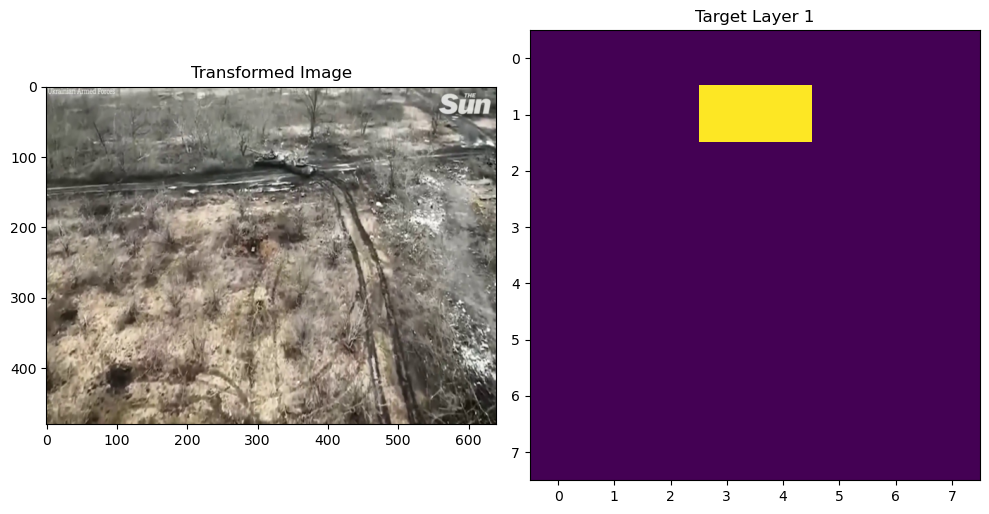

In [36]:
# prompt: visualize target tensor layer 0 and 1 matrix in sublplots

import matplotlib.pyplot as plt

img, target = train_dataset[0]
# Visualize target tensor layers 0 and 1
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# # Layer 0
# Layer 0 - Display the transformed image
axes[0].imshow(img.permute(1, 2, 0)) # Permute dimensions from (C, H, W) to (H, W, C) for imshow
axes[0].set_title('Transformed Image')

# Layer 1
axes[1].imshow(target[:, :, 4], cmap='viridis')
axes[1].set_title('Target Layer 1')

plt.tight_layout()
plt.show()


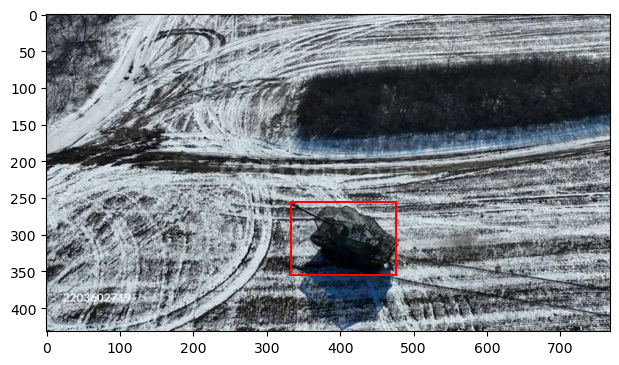

In [37]:
img, boxes = dataset.get_original_img(0)

plt.figure(figsize=(16, 16))
plt.subplot(121)
plt.imshow(img)

for box in boxes:
    cx, cy, width, height = box
    draw_rectangle(plt.gca(), cx - width // 2, cy - height // 2, width, height)

plt.show()

In [38]:
batch_size = 8
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [39]:
def rel_to_abs_coord(bbox, grid_id_y, grid_id_x, img_width=img_width, img_height=img_height, cell_width=cell_width, cell_height=cell_height):
  """
  Convert grid-level coordinates into image-level coordinates
  """
  center_x = cell_width * grid_id_x + cell_width * (bbox[0]+ 1)/2
  center_y = cell_height * grid_id_y + cell_height * (bbox[1]+ 1)/2
  width = bbox[2] * img_width
  height = bbox[3] * img_height

  return (center_x, center_y, width, height)

def visualize_with_targets(ax, img, targets,  confidence_threshold = 0.5):
    """
    Visualize an image with bounding boxes on a given matplotlib axis.
    """
    if isinstance(img, torch.Tensor):
        img = img.permute(1, 2, 0).numpy()

    ax.imshow(img)
    ax.axis('off')

    if isinstance(targets, torch.Tensor):
        grid_height, grid_width = targets.size()[:2]
    else:
        grid_height, grid_width = targets.shape[:2]
    img_height, img_width = img.shape[:2]
    cell_width = img_width / grid_width
    cell_height = img_height / grid_height

    # Draw grid lines
    for x in range(1, grid_width):
        ax.axvline(x=cell_width * x, color='white', linestyle='-', linewidth=1)
    for y in range(1, grid_height):
        ax.axhline(y=cell_height * y, color='white', linestyle='-', linewidth=1)

    # Iterate over grid cells to draw bounding boxes
    for grid_id_y, grid_id_x in np.stack(np.where(targets[...,4] >= confidence_threshold), axis = -1):

      # Convert center coordinates and sizes back into image coordinates
      center_x, center_y, width, height = rel_to_abs_coord(targets[grid_id_y, grid_id_x, 0:4], grid_id_y, grid_id_x)
      top_left_x = center_x - (width / 2)
      top_left_y = center_y - (height / 2)


      class_id = torch.argmax(targets[grid_id_y, grid_id_x, :4])
      # Filter out very small bboxes
      # if (width / img_width) > 0.1 and (height / img_height) > 0.1:
      draw_rectangle(ax, top_left_x, top_left_y, width, height, 'red')

      #adding centers to the image
      ax.scatter(center_x, center_y, color='red', s = 30)


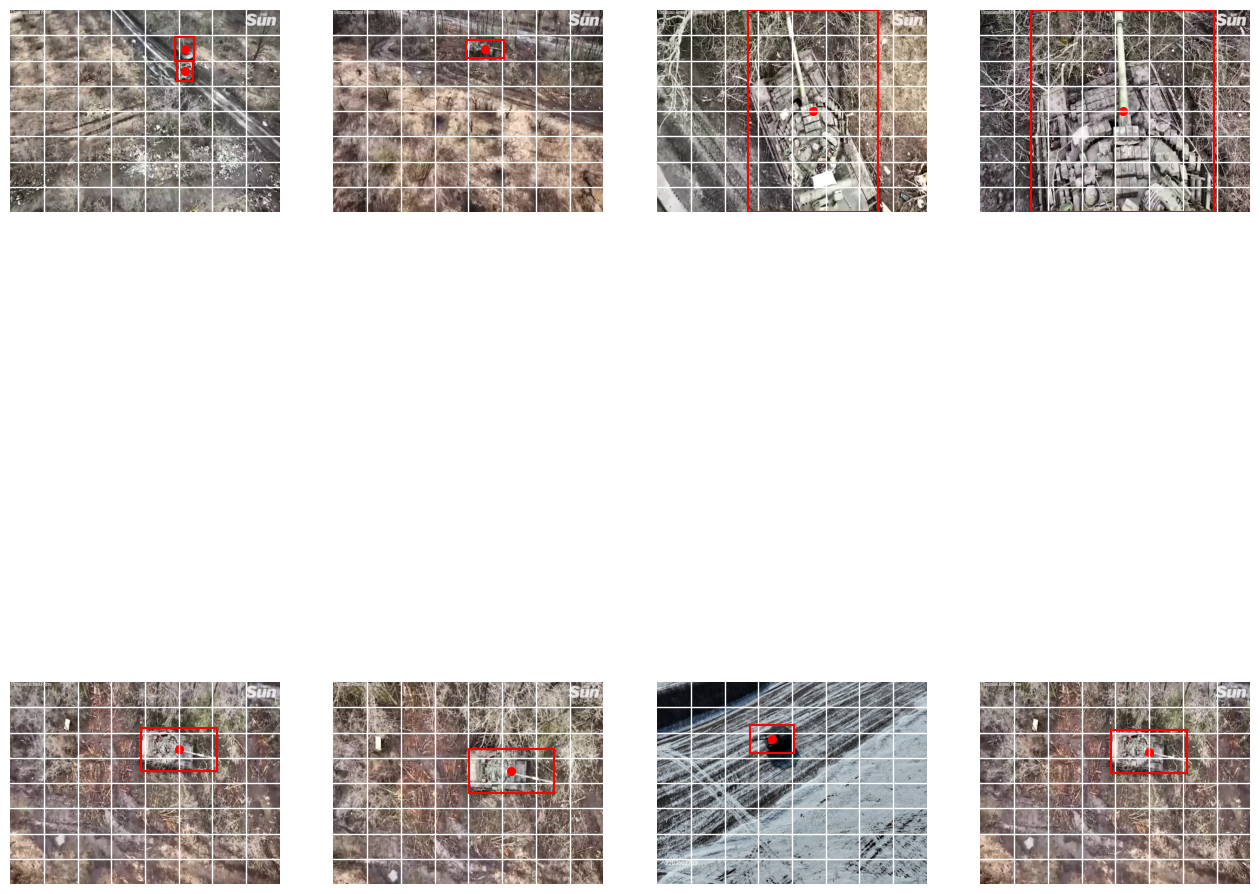

In [40]:
for image_batch, targets_batch in val_loader:
    fig, axes = plt.subplots(2, 4, figsize=(16, 16))
    axes = axes.flatten()

    for i in range(batch_size):
      ax = axes[i]
      img = image_batch[i]  # Current image tensor
      targets = targets_batch[i]  # Corresponding targets tensor

      # Call the visualization function for the current subplot axis
      visualize_with_targets(ax, img, targets, confidence_threshold = 0.35) # feel free to change the confidence threshold
    plt.show()
    break


In [41]:
import torch
import torch.nn as nn # all the relevant building blocks
import torch.nn.functional as F # functional interfaces for many operations
from torch.utils.data import DataLoader # provides tools to work with data
import torch.optim as optim

class AdvancedObjectDetector(nn.Module):
    def __init__(self, grid_height=grid_height, grid_width=grid_width, num_kernels=8, img_width = img_width, img_height = img_height):
        super(AdvancedObjectDetector, self).__init__()
        self.grid_height = grid_height
        self.grid_width = grid_width
 
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, num_kernels, kernel_size = 3, padding = 'same'),
            nn.BatchNorm2d(num_kernels),
            nn.ReLU(),
            nn.Conv2d(num_kernels, num_kernels, kernel_size = 3, padding = 'same'),
            nn.BatchNorm2d(num_kernels),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size = 2, stride = 2)
            )

        num_kernels *= 2
        self.conv2 = nn.Sequential(
          nn.Conv2d(num_kernels // 2, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.Conv2d(num_kernels, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2, stride = 2)
          )

        num_kernels *= 2
        self.conv3 = nn.Sequential(
          nn.Conv2d(num_kernels // 2, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.Conv2d(num_kernels, num_kernels, kernel_size = 3, padding = 'same'),
          nn.BatchNorm2d(num_kernels),
          nn.ReLU(),
          nn.MaxPool2d(kernel_size = 2, stride = 2)
          )



        N = 5 * grid_height * grid_width
        self.drop = nn.Dropout(p=0.3)

        self.fc = nn.Linear((img_width // 8) * (img_height // 8) * num_kernels, N)

    def forward(self, x):
        # Feedforward path in PyTorch
        x = self.conv1(x) # convolutional layer
        # x = self.batch(x)
        # x = self.relu(x)
        # x = self.maxpool(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), - 1) # Flatten the tensor before linear layer
        x = self.drop(x)
        x = self.fc(x) # Linear layer
        # Reshape to [batch_size, grid_height, grid_width, K+4+1]
        x = x.view(-1, self.grid_height, self.grid_width, 5)

        # Softmax if we had to use it would have been here:
        # x[..., 0:self.K] = torch.Softmax(x[..., 0:self.K]) # first K are responsible for K classes

        # Apply tanh to object center coordinates (assumed to be the next two values after class scores)
        x[..., 0:2] = torch.tanh(x[..., :2])

        # Apply sigmoid to width, height, and confidence (the next three values)
        x[..., 2:5] = torch.sigmoid(x[..., 2:5])
        return x

In [42]:
import torch
import torch.nn as nn # all the relevant building blocks
import torch.nn.functional as F # functional interfaces for many operations
from torch.utils.data import Dataset, DataLoader # abstract primitives for handling data in pytorch
from torchvision import transforms

if torch.cuda.is_available():
    print("GPU is available")
    device = torch.device("cuda")
else:
    print("GPU is not available, using CPU instead")
    device = torch.device("cpu")

GPU is available


In [43]:
import datetime
import torch

def save_model(model,  filename_prefix="model_state"):
    """Saves the model's state dictionary to a file named with a timestamp."""
    now = datetime.datetime.now()
    filename = f"{filename_prefix}.pth"
    torch.save(model.state_dict(), filename)
    print(f"Model saved to {filename}")
    return filename

def load_model(model, filename):
    """Loads the model's state dictionary from a file, moves it to the device, and sets it to evaluation mode."""
    # Ensure the model instance exists and has the correct architecture
    state_dict = torch.load(filename, map_location=device)
    model.load_state_dict(state_dict)
    print(f"Model state loaded from {filename}")
    return model



In [44]:
import json
import os

def save_history(history, filename_prefix="history"):
    """Saves the history dictionary to a JSON file."""
    filename = f"{filename_prefix}.json"
    try:
        # Convert tensors in history to lists if necessary (though history usually contains basic types)
        serializable_history = {}
        for key, value in history.items():
            if isinstance(value, list):
                 # Assuming list items are numbers or basic types, otherwise more conversion needed
                serializable_history[key] = value
            else:
                # Handle other potential types if needed, converting them to JSON serializable formats
                 serializable_history[key] = value # Fallback, might need adjustment based on actual content
        
        with open(filename, 'w') as f:
            json.dump(serializable_history, f, indent=4)
        print(f"History saved to {filename}")
    except Exception as e:
        print(f"Error saving history to {filename}: {e}")
    return filename

def load_history(filename_prefix="history"):
    """Loads the history dictionary from a JSON file."""
    filename = f"{filename_prefix}.json"
    default_history = {'loss': [], 'val_loss': []}
    if os.path.exists(filename):
        try:
            with open(filename, 'r') as f:
                history = json.load(f)
            print(f"History loaded from {filename}")
            # Ensure the essential keys exist, initialize if not
            if 'loss' not in history: history['loss'] = []
            if 'val_loss' not in history: history['val_loss'] = []
            return history
        except json.JSONDecodeError:
            print(f"Error decoding JSON from {filename}. Starting with empty history.")
            return default_history
        except Exception as e:
            print(f"Error loading history from {filename}: {e}. Starting with empty history.")
            return default_history
    else:
        print(f"History file {filename} not found. Starting with empty history.")
        return default_history

# Example Usage (You would integrate this into your training workflow)
# Assuming 'history' is your dictionary from the fit function and 'version' is defined

# Before training:
# history = load_history(filename_prefix=f"history_{version}")

# After training (e.g., in cell 22 after saving the model):
# save_history(history, filename_prefix=f"history_{version}")

In [45]:
bbox_loss = nn.MSELoss()  # For bounding box coordinates and sizes
confidence_loss = nn.BCELoss()  # For object confidence scores

def compute_loss(predictions, targets, lambda_coord=5, lambda_noobj=0.5, verbal=True):
    # Extract predictions
    pred_coords = predictions[..., 0:2]  # Next two channels for coordinates
    pred_sizes = predictions[..., 2:4]  # Sizes (width and height)
    pred_confidence = predictions[..., 4]  # Confidence scores

    # Similar extraction needs to be done for targets based on our dataset structure
    # Extract targets
    targets_coords = targets[..., 0:2]
    targets_sizes = targets[..., 2:4]
    targets_confidence = targets[..., 4]

    # Compute losses for each part

    loss_coords = bbox_loss(pred_coords, targets_coords)
    loss_sizes = bbox_loss(pred_sizes, targets_sizes)
    loss_confidence = confidence_loss(pred_confidence, targets_confidence)

    if verbal:
      print(f'Coordinates loss: {loss_coords}; Sizes loss: {loss_sizes}; Confidence loss: {loss_confidence}')

    # Combine losses
    total_loss = loss_coords + lambda_coord * loss_sizes + lambda_noobj * loss_confidence

    return total_loss

In [46]:
def fit(model, loss_func, train_loader, val_loader, n_epochs, optimizer, history=None):
  if history is None:
    history = {'loss': [], 'val_loss': []}

  for epoch in range(n_epochs):
    # initialise losses for logging
    epoch_loss, val_epoch_loss = 0.0, 0.0

    model.train()
    for images, targets in train_loader:
        images, targets = images.to(device), targets.to(device)
        optimizer.zero_grad()   # reseting gradients

        # Forward pass
        outputs = model(images)

        loss = loss_func(outputs, targets, verbal=False)

        # Backward and optimize
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    model.eval()
    with torch.inference_mode():
      for images, targets in val_loader:
          images, targets = images.to(device), targets.to(device)

          # Forward pass only
          outputs = model(images)
          loss = loss_func(outputs, targets, verbal=False)

          val_epoch_loss += loss.item()

    history['loss'].append(epoch_loss/len(train_loader))
    history['val_loss'].append(val_epoch_loss/len(val_loader))

    print(f"Epoch {epoch + 1}, Loss: {history['loss'][-1]}, Val loss: {history['val_loss'][-1]}")

  return history

In [47]:
def plot_curves(history):
  plt.figure(figsize=(16, 6))

  plt.subplot(1, 2, 1)
  plt.plot(history['loss'])
  plt.plot(history['val_loss'])
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.legend(['Training', 'Validation'])
  plt.title('Loss')

Loading model from models/model_state_v56.pth
Model state loaded from models/model_state_v56.pth


/tmp/ipykernel_1368206/4057364468.py:15: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(filename, map_location=device)


History loaded from models/history_v56.json


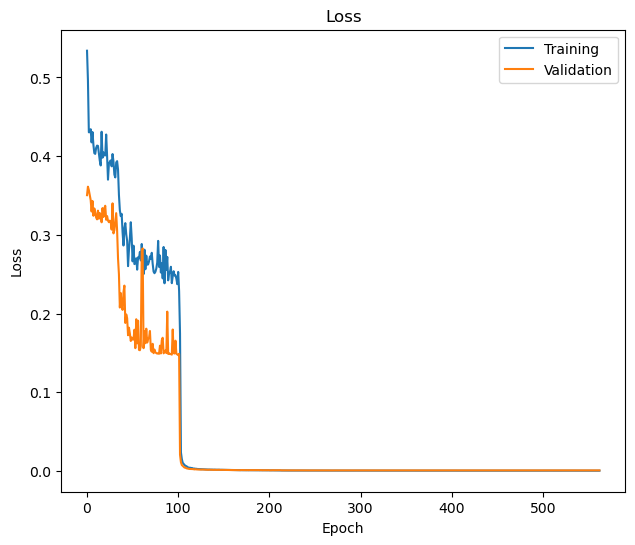

In [48]:
version = 56

# Load the model state
model_path = f"models/model_state_v{version}.pth"
obj_detection_model = AdvancedObjectDetector(grid_height=grid_height, grid_width=grid_width,  img_width=img_width, img_height=img_height)

if os.path.exists(model_path):
    print(f"Loading model from {model_path}")
    obj_detection_model = load_model(obj_detection_model, model_path)
else:
    raise FileNotFoundError(f"Model file {model_path} not found. ")

obj_detection_model = obj_detection_model.to(device)
# set model to inference mode
obj_detection_model.eval()

history = load_history(filename_prefix=f"models/history_v{version}")

plot_curves(history)



8


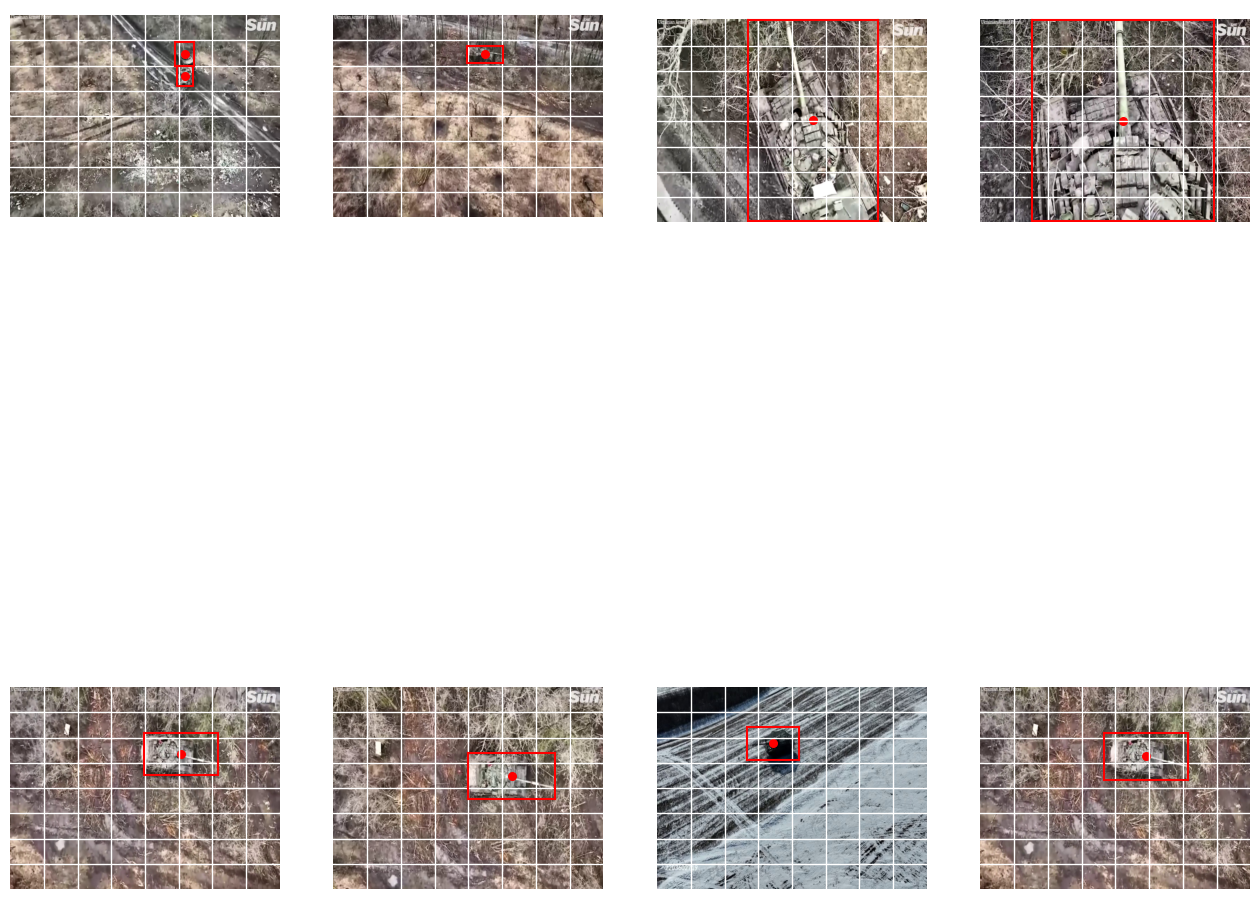

In [49]:
val_predictions = []

for image_batch, targets_batch in val_loader:
  print(len(image_batch))
  with torch.inference_mode(): # disable gradient calculation
      # only feedforward pass
      val_preds = obj_detection_model(image_batch.to(device))
      val_preds = val_preds.detach().cpu()

      # save predictions to later be able to work with them
      val_predictions.append(val_preds.numpy())

      fig, axes = plt.subplots(2, 4, figsize=(16, 16))
      axes = axes.flatten()

      for i in range(batch_size):
          ax = axes[i]
          img = image_batch[i]  # Current image tensor
          targets = val_preds[i]  # Corresponding targets tensor

          # Call the visualization function for the current subplot axis
          visualize_with_targets(ax, img, targets, confidence_threshold = 0.35)
      plt.show()
      break    


In [50]:
def get_iou_bbox(ground_truth_box, predicted_box):
  """
  ground_truth_box: center_x, center_y, width, height
  predicted_box: center_x, center_y, width, height
  """
  #### YOUR CODE STARTS HERE ####
  # Convert ground truth box from center format to (xmin, ymin, xmax, ymax)
  gt_cx, gt_cy, gt_w, gt_h = ground_truth_box
  gt_xmin = gt_cx - gt_w / 2
  gt_ymin = gt_cy - gt_h / 2
  gt_xmax = gt_cx + gt_w / 2
  gt_ymax = gt_cy + gt_h / 2

  # Convert predicted box from center format to (xmin, ymin, xmax, ymax)
  pred_cx, pred_cy, pred_w, pred_h = predicted_box
  pred_xmin = pred_cx - pred_w / 2
  pred_ymin = pred_cy - pred_h / 2
  pred_xmax = pred_cx + pred_w / 2
  pred_ymax = pred_cy + pred_h / 2

  # Compute the coordinates of the intersection rectangle
  inter_xmin = max(gt_xmin, pred_xmin)
  inter_ymin = max(gt_ymin, pred_ymin)
  inter_xmax = min(gt_xmax, pred_xmax)
  inter_ymax = min(gt_ymax, pred_ymax)

  # Compute width and height of the intersection rectangle
  inter_w = max(0, inter_xmax - inter_xmin)
  inter_h = max(0, inter_ymax - inter_ymin)
  inter_area = inter_w * inter_h

  # Compute the area of each box
  gt_area = gt_w * gt_h
  pred_area = pred_w * pred_h

  # Compute the union area
  union_area = gt_area + pred_area - inter_area

  # Calculate IoU, taking care to avoid division by zero
  iou = inter_area / union_area if union_area > 0 else 0.0
  #### YOUR CODE ENDS HERE ####

  return iou

In [51]:
def evaluate_obj_detection(predictions, loader, confidence_threshold=0.35, iou_threshold=0.5):
    """
    Evaluates object detection performance.

    Args:
            predictions: A list of numpy arrays, where each array corresponds to a batch
                                     and has shape (batch_size, grid_height, grid_width, 5).
                                     The last dimension contains [cx, cy, w, h, confidence].
            loader: DataLoader providing batches of (images, targets). Targets have the
                            same shape structure as predictions.
            confidence_threshold: Minimum confidence score to consider a prediction as an object.
            iou_threshold: Minimum IoU score for a prediction to be considered a match
                                         with a ground truth box.

    Returns:
            A tuple containing:
            - ious (list): A list of IoU scores for matched ground truth boxes.
            - class_predictions (list): A list of predicted class indices (0 for matched object,
                                                                     1 for unmatched/background).
    """
    ious = []
    class_predictions = []

    for batch_indx, (images, targets) in enumerate(loader):
        targets = targets.numpy() # Shape: (batch_size, grid_height, grid_width, 5)
        batch_preds = predictions[batch_indx] # Shape: (batch_size, grid_height, grid_width, 5)

        for img_indx in range(targets.shape[0]):
            img_targets = targets[img_indx] # Shape: (grid_height, grid_width, 5)
            img_preds = np.copy(batch_preds[img_indx]) # Shape: (grid_height, grid_width, 5)

            # Find all grid cells with predicted objects in the current image prediction
            # The confidence score is at index 4
            pred_grid_ids = np.stack(np.where(img_preds[:, :, 4] >= confidence_threshold), axis=-1)

            # Find all grid cells with ground truth objects in the current image target
            # The confidence score (object presence) is at index 4
            gt_grid_ids = np.stack(np.where(img_targets[:, :, 4] >= confidence_threshold), axis=-1) # Using confidence_threshold for GT assumes GT confidence is 1

            # Keep track of which predictions have been matched
            matched_preds = np.zeros(len(pred_grid_ids), dtype=bool)

            for grid_id_y_gt, grid_id_x_gt in gt_grid_ids:
                # Get the ground truth bounding box [cx, cy, w, h] (indices 0 to 3)
                gt_bbox_rel = img_targets[grid_id_y_gt, grid_id_x_gt, 0:4]
                # Convert to absolute coordinates
                gt_bbox_abs = rel_to_abs_coord(gt_bbox_rel, grid_id_y_gt, grid_id_x_gt)

                # Calculate IoU with all *unmatched* predicted bboxes
                gt_bbox_ious = []
                pred_indices_for_gt = [] # Store indices of predictions considered for this GT box
                for i, (grid_id_y_p, grid_id_x_p) in enumerate(pred_grid_ids):
                        if not matched_preds[i]: # Only consider predictions not yet matched
                                pred_bbox_rel = img_preds[grid_id_y_p, grid_id_x_p, 0:4]
                                pred_bbox_abs = rel_to_abs_coord(pred_bbox_rel, grid_id_y_p, grid_id_x_p)
                                iou = get_iou_bbox(gt_bbox_abs, pred_bbox_abs)
                                gt_bbox_ious.append(iou)
                                pred_indices_for_gt.append(i)

                if not gt_bbox_ious: # No available predictions left for this GT box
                        max_iou = 0
                else:
                        max_iou = np.max(gt_bbox_ious)

                if max_iou > iou_threshold:
                        ious.append(max_iou)

                        # Find the index of the best matching prediction among the considered ones
                        best_pred_local_idx = np.argmax(gt_bbox_ious)
                        # Get the original index in pred_grid_ids
                        best_pred_global_idx = pred_indices_for_gt[best_pred_local_idx]

                        # Mark this prediction as matched
                        matched_preds[best_pred_global_idx] = True

                        # Since there are no explicit classes, assign class 0 for a match
                        class_predictions.append(0)

                else: # Ground truth box not matched by any prediction above the threshold
                        ious.append(0)
                        # Assign class 1 for non-detection/background
                        class_predictions.append(1)

    return ious, class_predictions

In [52]:
# Set the model to evaluation mode
obj_detection_model.eval()

val_predictions = []

for image_batch, targets_batch in val_loader:
  with torch.inference_mode(): # disable gradient calculation
      # only feedforward pass
      val_preds = obj_detection_model(image_batch.to(device))
      val_preds = val_preds.detach().cpu()

      # save predictions to later be able to work with them
      val_predictions.append(val_preds.numpy())

In [53]:
# Set the model to evaluation mode
obj_detection_model.eval()

val_predictions = []

for image_batch, targets_batch in val_loader:
  with torch.inference_mode(): # disable gradient calculation
      # only feedforward pass
      val_preds = obj_detection_model(image_batch.to(device))
      val_preds = val_preds.detach().cpu()

      # save predictions to later be able to work with them
      val_predictions.append(val_preds.numpy())

In [54]:

ious, object_classes = evaluate_obj_detection(val_predictions, val_loader,  confidence_threshold=0.35) # feel free to change the confidence threshold
mean_iou = np.mean(ious)

print(f'Mean IoU is {np.round(mean_iou, 3)}')

Mean IoU is 0.898


# GENERATING TEST PREDICTIONS

In [55]:
import torch
import os
from PIL import Image
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import csv

# Define a Dataset for the test images
class TestImageDataset(Dataset):
    def __init__(self, dataset_dir, img_width, img_height):
        self.dataset_dir = dataset_dir
        self.img_width = img_width
        self.img_height = img_height
        frames_dir = os.path.join(dataset_dir, 'frames')
        # List all jpg files, sort them numerically based on the frame index
        self.image_files = sorted(
            [f for f in os.listdir(frames_dir) if f.endswith('.jpg') and f.startswith('frame_')],
            key=lambda x: int(x.split('_')[1].split('.')[0])
        )
        self.transform = transforms.Compose([
            transforms.Resize((self.img_height, self.img_width)),
            transforms.ToTensor()
        ])

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.dataset_dir, 'frames', self.image_files[idx])
        img = Image.open(img_path).convert('RGB') # Ensure image is RGB
        transformed_img = self.transform(img)
        # Extract image_id from filename (e.g., frame_0.jpg -> 0)
        image_id = int(self.image_files[idx].split('_')[1].split('.')[0])
        return transformed_img, image_id

# --- Parameters ---
test_folder = os.path.join(data_folder, "test")
# Assuming img_width, img_height, grid_width, grid_height, cell_width, cell_height are defined in previous cells
# Assuming obj_detection_model is loaded and on the correct device (from cell 20 or loaded separately)
# Assuming rel_to_abs_coord function is defined (from cell 11)
confidence_threshold = 0.35 # Use the same threshold as validation or tune as needed
output_csv_file = "submission.csv"
test_batch_size = batch_size # Use the same batch size or adjust

# --- Create Test Dataset and DataLoader ---
test_dataset = TestImageDataset(test_folder, img_width=img_width, img_height=img_height)
test_loader = DataLoader(test_dataset, batch_size=test_batch_size, shuffle=False)

# --- Generate Predictions ---
obj_detection_model.eval() # Set model to evaluation mode
all_predictions = {} # Dictionary to store predictions: {image_id: {'x_min': [], 'y_min': [], 'x_max': [], 'y_max': []}}

with torch.inference_mode():
    for image_batch, image_ids_batch in test_loader:
        image_batch = image_batch.to(device)
        preds_batch = obj_detection_model(image_batch)
        preds_batch = preds_batch.detach().cpu().numpy() # Shape: (batch_size, grid_h, grid_w, 5)

        for i in range(preds_batch.shape[0]):
            img_preds = preds_batch[i] # Shape: (grid_h, grid_w, 5)
            image_id = image_ids_batch[i].item()

            if image_id not in all_predictions:
                 all_predictions[image_id] = {'x_min': [], 'y_min': [], 'x_max': [], 'y_max': []}

            # Find grid cells with confidence above threshold
            pred_grid_ids = np.stack(np.where(img_preds[:, :, 4] >= confidence_threshold), axis=-1)

            for grid_id_y, grid_id_x in pred_grid_ids:
                pred_bbox_rel = img_preds[grid_id_y, grid_id_x, 0:4]
                # Convert relative grid coords to absolute image coords (cx, cy, w, h)
                # load original image to get its true size
                orig_path = os.path.join(test_folder, 'frames', f'frame_{image_id}.jpg')
                orig_img = Image.open(orig_path)
                orig_w, orig_h = orig_img.size

                # get bbox on the resized image
                cx_resized, cy_resized, w_resized, h_resized = rel_to_abs_coord(
                    pred_bbox_rel, grid_id_y, grid_id_x,
                    img_width=img_width, img_height=img_height,
                    cell_width=cell_width, cell_height=cell_height
                )

                # scale back to original image dimensions
                center_x = cx_resized * orig_w / img_width
                center_y = cy_resized * orig_h / img_height
                width    = w_resized * orig_w / img_width
                height   = h_resized * orig_h / img_height

                # Convert absolute (cx, cy, w, h) to (xmin, ymin, xmax, ymax)
                x_min = int(max(0, center_x - width / 2))
                y_min = int(max(0, center_y - height / 2))
                x_max = int(min(orig_w, center_x + width / 2))
                y_max = int(min(orig_h, center_y + height / 2))

                # Add valid bounding box to the predictions for this image_id
                if x_min < x_max and y_min < y_max: # Basic validity check
                    all_predictions[image_id]['x_min'].append(x_min)
                    all_predictions[image_id]['y_min'].append(y_min)
                    all_predictions[image_id]['x_max'].append(x_max)
                    all_predictions[image_id]['y_max'].append(y_max)


# --- Write to CSV ---
num_test_images = len(test_dataset.image_files) # Total number of images expected in submission

with open(output_csv_file, mode='w', newline='') as file:
    writer = csv.writer(file, delimiter=",")
    writer.writerow(["image_id", "x_min", "y_min", "x_max", "y_max", "class_id"])

    # Ensure all image IDs from 0 to num_test_images-1 are present
    for image_id in range(num_test_images):
        #if image_id in all_predictions and all_predictions[image_id]['x_min']: # Check if predictions exist and are not empty
        preds = all_predictions[image_id]
        # Format coordinates as space-separated strings
        x_min_str = ";".join(map(str, preds['x_min']))
        y_min_str = ";".join(map(str, preds['y_min']))
        x_max_str = ";".join(map(str, preds['x_max']))
        y_max_str = ";".join(map(str, preds['y_max']))
        class_id = 0 # Assuming single class with ID 0
        writer.writerow([image_id, x_min_str, y_min_str, x_max_str, y_max_str, class_id])


print(f"Predictions saved to {output_csv_file}")

# Optional: Display head of the generated file
!head {output_csv_file}

Predictions saved to submission.csv
image_id,x_min,y_min,x_max,y_max,class_id
0,828;1033,201;260,1035;1152,289;325,0
1,850;1021,201;217,1022;1168,267;295,0
2,315,255,469,359,0
3,699,62,1443,1080,0
4,880,242,1473,496,0
5,431;1355,460;560,556;1468,581;625,0
6,946,164,1214,263,0
7,927,316,1494,571,0
8,705,677,1030,826,0


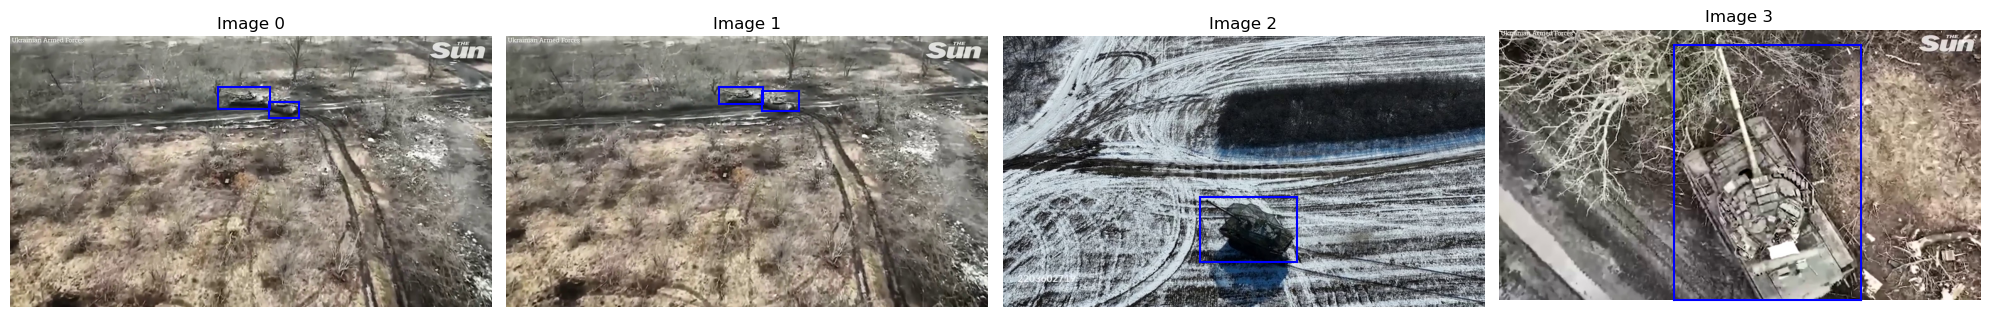

In [57]:
# Visualize a few predictions on original images
sample_ids = list(all_predictions.keys())[:4]  # pick first 4 images to display
fig, axes = plt.subplots(1, len(sample_ids), figsize=(5 * len(sample_ids), 5))

for ax, image_id in zip(axes, sample_ids):
    # load the original image
    img_path = os.path.join(test_folder, 'frames', f'frame_{image_id}.jpg')
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f'Image {image_id}')
    
    # draw each predicted box
    preds = all_predictions[image_id]
    for xmin, ymin, xmax, ymax in zip(preds['x_min'],
                                      preds['y_min'],
                                      preds['x_max'],
                                      preds['y_max']):
        w = xmax - xmin
        h = ymax - ymin
        draw_rectangle(ax, xmin, ymin, w, h, color='blue')

plt.tight_layout()
plt.show()